In [9]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image_dataset_from_directory

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

# sicherstellen, dass du im Projekt-Ordner bist
# os.chdir("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

train_dir = Path("dataset/train")
val_dir   = Path("dataset/val")
test_dir  = Path("dataset/test")


In [10]:
import os
os.chdir("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning")
print("Neuer cwd:", os.getcwd())


Neuer cwd: /Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning


In [11]:
def load_binary_dataset(directory, shuffle):
    ds = image_dataset_from_directory(
        directory,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        label_mode="int"
    )

    class_names    = ds.class_names
    class_names_tf = tf.constant(class_names)

    def to_binary(x, y):
        # y sind Indizes in class_names
        names       = tf.gather(class_names_tf, y)
        names_lower = tf.strings.lower(names)
        is_healthy  = tf.strings.regex_full_match(names_lower, ".*healthy.*")
        y_bin       = tf.where(is_healthy, 0, 1)     # healthy = 0, sonst = 1
        return x, tf.cast(y_bin, tf.int32)

    return ds.map(to_binary), class_names

train_ds, train_classes = load_binary_dataset(train_dir, shuffle=True)
val_ds,   _             = load_binary_dataset(val_dir,   shuffle=False)
test_ds,  _             = load_binary_dataset(test_dir,  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

# kleiner Check
labels_check = []
for _, yb in train_ds.take(3):
    labels_check.extend(yb.numpy().tolist())
print("Beispiel-Labels (sollte 0 und 1 enthalten):", set(labels_check))


Found 14440 files belonging to 16 classes.
Found 3089 files belonging to 16 classes.
Found 3109 files belonging to 16 classes.


2025-11-05 20:05:06.470935: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_17' with dtype string and shape [16]
	 [[{{node Placeholder/_17}}]]
2025-11-05 20:05:06.471257: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_17' with dtype string and shape [16]
	 [[{{node Placeholder/_17}}]]


Beispiel-Labels (sollte 0 und 1 enthalten): {0, 1}


In [12]:
all_train_labels = []
for _, yb in train_ds:
    all_train_labels.extend(yb.numpy())
all_train_labels = np.array(all_train_labels)

classes = np.unique(all_train_labels)
weights = compute_class_weight(class_weight="balanced",
                               classes=classes,
                               y=all_train_labels)
class_weight = {int(c): float(w) for c, w in zip(classes, weights)}
print("class_weight:", class_weight)


2025-11-05 20:05:06.729156: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_17' with dtype string and shape [16]
	 [[{{node Placeholder/_17}}]]
2025-11-05 20:05:06.729437: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [14440]
	 [[{{node Placeholder/_4}}]]


class_weight: {0: 3.2046160674656012, 1: 0.5924345614179043}


In [13]:
def make_plant_cnn(input_shape=IMG_SIZE + (3,)):
    inputs = keras.Input(shape=input_shape)

    # Datenaugmentation – damit das Netz robust gegen Licht/Hintergrund wird
    data_aug = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomBrightness(0.2),
        layers.RandomContrast(0.2),
    ], name="data_augmentation")

    x = data_aug(inputs)
    x = layers.Rescaling(1./255, name="rescale")(x)

    # Block 1 – eher grobe Kanten / Formen
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2 – feinere Muster
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 – noch tiefer (Flecken, Texturen der Blätter)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Optional Block 4 – für sehr große Varianz im Datensatz
    x = layers.Conv2D(256, (3, 3), padding="same", activation="relu")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Dropout(0.5)(x)
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)

    # Binary-Output: 1 Neuron mit Sigmoid
    outputs = layers.Dense(1, activation="sigmoid", name="binary_output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="plant_cnn_from_scratch")
    return model

plant_cnn = make_plant_cnn()
plant_cnn.summary()

plant_cnn.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


Model: "plant_cnn_from_scratch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 data_augmentation (Sequenti  (None, 224, 224, 3)      0         
 al)                                                             
                                                                 
 rescale (Rescaling)         (None, 224, 224, 3)       0         
                                                                 
 conv2d_7 (Conv2D)           (None, 224, 224, 32)      896       
                                                                 
 conv2d_8 (Conv2D)           (None, 224, 224, 32)      9248      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 112, 112, 32)     0         
 2D)                                        

In [14]:
EPOCHS = 20  # kannst du später auf 30–40 erhöhen, wenn es stabil trainiert

history = plant_cnn.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    class_weight=class_weight   # hilft, falls Healthy/Diseased unbalanciert
)

plant_cnn.save("plant_cnn_from_scratch_binary.keras")


Epoch 1/20


2025-11-05 20:05:09.896798: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_21' with dtype float and shape [2]
	 [[{{node Placeholder/_21}}]]
2025-11-05 20:05:09.897212: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [14440]
	 [[{{node Placeholder/_0}}]]
2025-11-05 20:05:10.723373: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.
2025-11-05 20:05:10.882013: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] model_pruner failed: INVALID_ARGUMENT: Graph does not contain termina

  1/452 [..............................] - ETA: 38:53 - loss: 0.6308 - accuracy: 0.5000

2025-11-05 20:05:15.101268: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-05 20:05:15.101868: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


  2/452 [..............................] - ETA: 2:34 - loss: 0.8106 - accuracy: 0.6094 

...

450/452 [============================>.] - ETA: 1s - loss: 0.0254 - accuracy: 0.9908

2025-11-05 21:24:41.299390: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-05 21:24:41.300139: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


451/452 [============================>.] - ETA: 0s - loss: 0.0256 - accuracy: 0.9907

2025-11-05 21:24:41.958936: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.
2025-11-05 21:24:41.959521: I metal_plugin/src/kernels/stateless_random_op.cc:282] Note the GPU implementation does not produce the same series as CPU implementation.


452/452 [==============================] - 351s 777ms/step - loss: 0.0256 - accuracy: 0.9907 - val_loss: 0.9928 - val_accuracy: 0.8168


2025-11-05 21:24:53.438708: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [3109]
	 [[{{node Placeholder/_4}}]]
2025-11-05 21:24:53.438993: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_12' with dtype string and shape [16]
	 [[{{node Placeholder/_12}}]]
2025-11-05 21:24:54.576441: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


98/98 [==============================] - 10s 98ms/step
📊 Classification Report – Plant-CNN:
              precision    recall  f1-score   support

     Healthy       0.45      1.00      0.62       487
    Diseased       1.00      0.78      0.87      2622

    accuracy                           0.81      3109
   macro avg       0.73      0.89      0.75      3109
weighted avg       0.91      0.81      0.83      3109



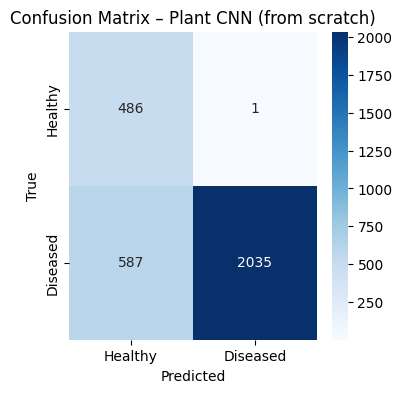

In [15]:
# echte Labels aus test_ds
y_true = np.concatenate([yb.numpy() for _, yb in test_ds])

# Sigmoid-Werte (0..1)
y_prob = plant_cnn.predict(test_ds).ravel()

# harte Klassen mit Threshold 0.5
y_pred = (y_prob > 0.5).astype(int)

print("📊 Classification Report – Plant-CNN:")
print(classification_report(y_true, y_pred, target_names=["Healthy", "Diseased"]))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Healthy", "Diseased"],
    yticklabels=["Healthy", "Diseased"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – Plant CNN (from scratch)")
plt.show()


In [19]:
import os
print(os.path.exists("../cnn_plant_disease_binary.keras"))


True


1/1 [==============================] - 0s 110ms/step


2025-11-05 23:17:44.871371: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


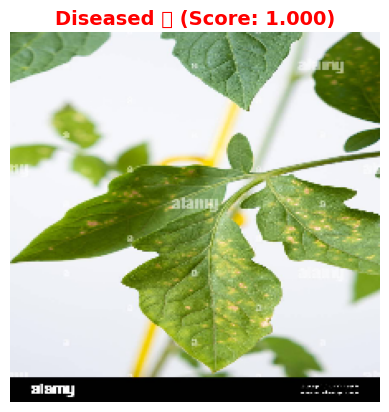

Rohwert (Sigmoid): 1.0000
Schwellenwert: 0.5
Vorhersage: Diseased 🌿


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow import keras

# Modell und Bildgröße festlegen
plant_cnn = keras.models.load_model("plant_cnn_from_scratch_binary.keras")  # ggf. Dateiname anpassen
IMG_SIZE = (224, 224)

def predict_image_plant_cnn(img_path, model=plant_cnn, thresh=0.5):
    # --- Bild laden ---
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = image.img_to_array(img)

    # WICHTIG: Kein /255, weil dein Modell die Rescaling-Schicht enthält!
    x = np.expand_dims(img_array, axis=0)

    # --- Vorhersage ---
    prob = model.predict(x)[0][0]  # Sigmoid-Ausgabe zwischen 0 und 1
    label = "Diseased 🌿" if prob > thresh else "Healthy 🍃"
    color = "red" if label.startswith("Diseased") else "green"

    # --- Anzeige ---
    plt.imshow(img)  # kein .astype(), img ist PIL-Objekt
    plt.axis("off")
    plt.title(f"{label} (Score: {prob:.3f})", color=color, fontsize=14, weight="bold")
    plt.show()

    print(f"Rohwert (Sigmoid): {prob:.4f}")
    print(f"Schwellenwert: {thresh}")
    print(f"Vorhersage: {label}")

# Beispielaufruf
predict_image_plant_cnn("/Users/umerhanif/Desktop/UNI/SEM5/KI & ML Projekt/KI-Machine-Learning/strichprobe(nicht_plant_village)/gelbe-flecken-auf-tomatenblattern-pflanzenkrankheiten-wahrend-des-gemuseanbaus-2k6cpha.jpg")
